In [1]:
# Connect Colab with your Google Drive for file read and write
from google.colab import drive
drive.mount('/content/drive')

# Set up the root path, where all assignment files will be stored
import os
root = "/content/drive/MyDrive/COMP4423_Assignment2"
os.makedirs(root, exist_ok=True) # Creates directory if it does not exist
print(f"root path: {root}")

Mounted at /content/drive
root path: /content/drive/MyDrive/COMP4423_Assignment2


In [2]:
import zipfile
import os

zip_path = os.path.join(root, "dataset.zip")

# Extract dataset.zip --> creates the dataset folder
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(root) # Extract all files from zip archive

print("Dataset unzipped!")

# Check structure verify extraction worked correctly
print(os.listdir(root)) # List contents of root folder
print(os.listdir(root + "/dataset")) # List contents of dataset folder

Dataset unzipped!
['dataset.zip', 'dataset', 'model.pkl']
['training', 'val']


In [4]:
import cv2
import numpy as np
from tqdm import tqdm # Progress bar for loading images

# Function to extract color histogram features from an image
# This converts a raw image into a numerical feature vector that the SVM can process
def extract_features(image_path):
    # Read image using OpenCV (BGR format)
    img = cv2.imread(image_path)


    img = cv2.resize(img, (128, 128))  # resize for consistency, 128 chosen as balance between detail and computational efficiency

    # Convert to HSV (better for color features)
    hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)

    # Compute histogram (color distribution)
    hist = cv2.calcHist([hsv], [0,1,2], None, [8,8,8],
                        [0,180, 0,256, 0,256])

    # Normalize histogram so values sum to 1
    hist = cv2.normalize(hist, hist).flatten()

    return hist

In [5]:
def load_dataset(folder):
    X = [] # Features
    y = [] # Labels

    # Get class names from subfolders
    class_names = os.listdir(folder)

    # Iterate through each class folder
    for label in class_names:
        class_path = os.path.join(folder, label)

        # Iterate through each image in the class folder
        for img_name in tqdm(os.listdir(class_path)):
            img_path = os.path.join(class_path, img_name)

            try:
                # Extract features and add to dataset
                features = extract_features(img_path)
                X.append(features)
                y.append(label)
            except:
                #Skip corrupted or unreadable images
                continue

    return np.array(X), np.array(y), class_names

In [6]:
# Define paths to training and validation folders
train_path = root + "/dataset/training"
val_path = root + "/dataset/val"

# Load training data
X_train, y_train, class_names = load_dataset(train_path)

# Load validation data
X_val, y_val, _ = load_dataset(val_path)

# Verify dataset dimensions
print("Train shape:", X_train.shape)
print("Val shape:", X_val.shape)
print("Classes:", class_names) # List of all plant categories

100%|██████████| 4/4 [00:00<00:00, 80.88it/s]

Train shape: (96, 512)
Val shape: (29, 512)
Classes: ['bougainvillea', 'cordyline_fruticosa', 'impatiens_walleriana', 'ixora', 'pentas_lanceolata', 'plumbago_auriculata', 'podocarpus_macrophyllus', 'rhaphiolepis_indica', 'schefflera_arboricola_variegated', 'tibouchina']


In [7]:
from sklearn.svm import SVC

# Create SVM classifier with RBF (Radial Basis Function) kernel
model = SVC(kernel='rbf', probability=True)

# Train model on extracted features
model.fit(X_train, y_train)

print("Model trained!")

Model trained!


Validation Accuracy: 0.896551724137931

Classification Report:
                                  precision    recall  f1-score   support

                   bougainvillea       1.00      0.75      0.86         4
             cordyline_fruticosa       1.00      1.00      1.00         3
            impatiens_walleriana       1.00      0.50      0.67         2
                           ixora       0.80      1.00      0.89         4
               pentas_lanceolata       0.75      1.00      0.86         3
             plumbago_auriculata       1.00      1.00      1.00         3
         podocarpus_macrophyllus       1.00      0.50      0.67         2
             rhaphiolepis_indica       0.67      1.00      0.80         2
schefflera_arboricola_variegated       1.00      1.00      1.00         2
                      tibouchina       1.00      1.00      1.00         4

                        accuracy                           0.90        29
                       macro avg       0.92    

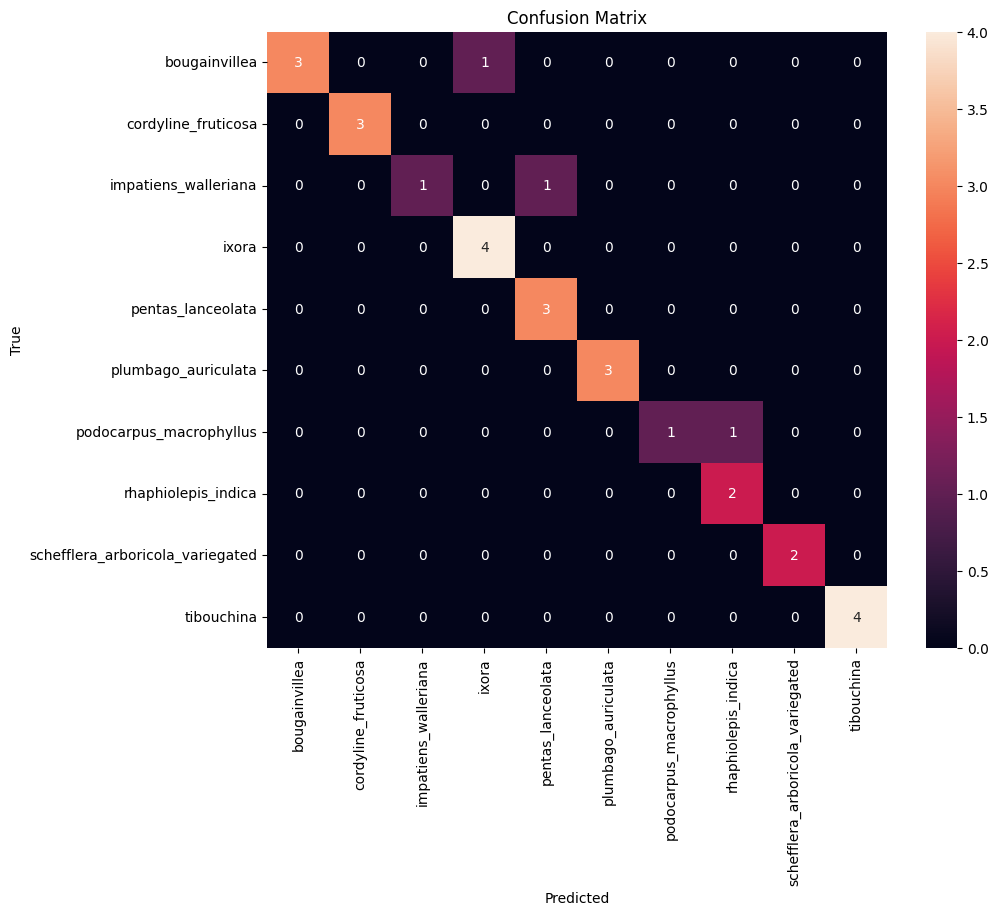

Training log saved to: /content/drive/MyDrive/COMP4423_Assignment2/train_log.txt


In [8]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Predict on validation set
y_pred = model.predict(X_val)

# Calculate and display overall accuracy
acc = accuracy_score(y_val, y_pred)
print("Validation Accuracy:", acc)

# Classification report shows precision, recall, F1-score for each class
print("\nClassification Report:")
print(classification_report(y_val, y_pred))

# Confusion matrix shows which classes are commonly confused with each other
cm = confusion_matrix(y_val, y_pred)

plt.figure(figsize=(10,8))
sns.heatmap(cm, annot=True, fmt='d',
            xticklabels=class_names,
            yticklabels=class_names)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()

# Save training log (required for Task 3 - reproducibility)
with open(root + "/train_log.txt", "w") as f:
    f.write("=== Training Log ===\n")
    f.write(f"Feature extraction: HSV color histogram (8x8x8 bins, 512 features)\n")
    f.write(f"Classifier: SVM with RBF kernel\n")
    f.write(f"Training samples: {len(X_train)}\n")
    f.write(f"Validation samples: {len(X_val)}\n")
    f.write(f"Validation accuracy: {acc:.4f}\n")
    f.write("\nClassification Report:\n")
    f.write(classification_report(y_val, y_pred))

print("Training log saved to:", root + "/train_log.txt")

In [10]:
import joblib

# Model saved for future use
model_path = root + "/model.pkl"
joblib.dump(model, model_path)

print("Model saved at:", model_path)

Model saved at: /content/drive/MyDrive/COMP4423_Assignment2/model.pkl


In [11]:
# Load model (just to simulate real use)
model = joblib.load(model_path)

def predict_image(image_path):
    features = extract_features(image_path)
    features = features.reshape(1, -1)

    prediction = model.predict(features)[0]
    confidence = np.max(model.predict_proba(features))

    return prediction, confidence

In [12]:
# Example test image
test_img = root + "/dataset/val/bougainvillea/IMG_8730.jpg"

pred, conf = predict_image(test_img)

print("Prediction:", pred)
print("Confidence:", conf)

Prediction: bougainvillea
Confidence: 0.6029472471348786


Plant Classification App
Upload an image to predict the plant species


Saving IMG_8648.jpeg to IMG_8648.jpeg


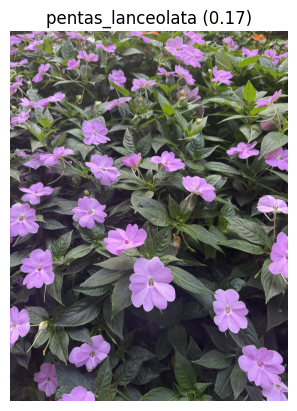

IMG_8648.jpeg → pentas_lanceolata (0.17)


In [13]:
"""
PLANT CLASSIFICATION APP - INSTRUCTIONS
=========================================
HOW TO LAUNCH AND USE:
1. Run all cells in this notebook sequentially from top to bottom
2. After the model finishes training, scroll down to this section
3. When you see "Choose Files" button appear, click it
4. Select one or more plant images from your computer
5. The app will display each image with its predicted class and confidence score

REQUIREMENTS:
- Images should be in JPG, JPEG, or PNG format
- For best results, use images with clear view of the plant (not too cluttered)
- Supported plant classes: bougainvillea, cordyline_fruticosa, impatiens_walleriana,
  ixora, pentas_lanceolata, plumbago_auriculata, podocarpus_macrophyllus,
  rhaphiolepis_indica, schefflera_arboricola_variegated, tibouchina

TROUBLESHOOTING:
- If upload button doesn't appear, re-run this cell
- If prediction seems incorrect, try images with simpler backgrounds
=========================================
"""

from google.colab import files
import matplotlib.pyplot as plt
import cv2

print("Plant Classification App")
print("Upload an image to predict the plant species")

# Allow users to upload images
uploaded = files.upload()

# Process each uploaded image
for filename in uploaded.keys():

    # Run prediction
    pred, conf = predict_image(filename)

    # Display image with prediction result
    img = cv2.imread(filename)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    plt.imshow(img)
    plt.title(f"{pred} ({conf:.2f})")
    plt.axis("off")
    plt.show()

    # Print result
    print(f"{filename} → {pred} ({conf:.2f})")